# Mô hình XGBoost cho dự báo giá vàng
1. Feature Engineering
2. Xây dựng mô hình XGBoost
3. Đánh giá và so sánh với baseline

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/processed/gold_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Từ: {df['date'].min().year} -> Đến: {df['date'].max().year}")
df.head()

Shape: (775, 5)
Từ: 2023 -> Đến: 2026


,date,open,high,low,close
0,2023-04-03,1970.84,1990.64,1949.82,1984.11
1,2023-04-04,1984.59,2025.19,1977.01,2019.97
2,2023-04-05,2020.44,2032.20,2009.99,2020.35
3,2023-04-06,2020.13,2021.63,2000.88,2008.02
4,2023-04-10,2008.30,2011.17,1981.59,1989.95


# 1. Feature Engineering
Tạo các đặc trưng từ dữ liệu OHLC gốc
** Các nhóm features **
- Lag feature: giá đóng cửa của 1, 2, 3, 5, 7 ngày trước
- Moving Average: Trung bình động của 5, 10, 20 ngày (sma_5, sma_10, sma_20)
- EMA: Trung bình động hàm mũ, nhấm mạnh dữ liệu gần hiện tại hơn SMA (ema_5, ema_10)
- Volatility: Biên độ dao động, độ lệch chuẩn, giá vàng phụ thuộc vào mức biến động gần đầy (rolling_std_5, rolling_std_10, daily_range = (high - low)/ close)
- Returns: Phần trăm thay đổi giá, tốc độ tăng/ giảm (return_1d, return_3d, return_5d)
- RSI: Chỉ báo quá mua/ quá bán - cân nhắc sau
- Day of week: Ngày trong tuần (date.dt.dayofweek) - cân nhắc sau
- close_open_diff = (close - open) / open : Phản ánh lực tăng/ giảm trong ngày
- high_low_spread = (high - low) / open : phản án biên độ dao động nội ngày

In [3]:
# Tạo feature cho XGBoost

# Tạo bản copy để làm feature engineering
df_feat = df.copy()

# =========================
# 1. Lag features
# =========================
for lag in [1, 2, 3, 5, 7]:
    df_feat[f"close_lag_{lag}"] = df_feat["close"].shift(lag)

# =========================
# 2. Simple Moving Average (SMA)
# =========================
for window in [5, 10, 20]:
    df_feat[f"sma_{window}"] = df_feat["close"].rolling(window=window).mean()

# =========================
# 3. Exponential Moving Average (EMA)
# =========================
for span in [5, 10]:
    df_feat[f"ema_{span}"] = df_feat["close"].ewm(span=span, adjust=False).mean()

# =========================
# 4. Volatility features
# =========================
for window in [5, 10]:
    df_feat[f"rolling_std_{window}"] = df_feat["close"].rolling(window=window).std()

# =========================
# 5. Return features
# =========================
df_feat["return_1d"] = df_feat["close"].pct_change(periods=1)
df_feat["return_3d"] = df_feat["close"].pct_change(periods=3)
df_feat["return_5d"] = df_feat["close"].pct_change(periods=5)

# =========================
# 6. Intraday spread / range
# =========================
df_feat["daily_range"] = (df_feat["high"] - df_feat["low"]) / df_feat["close"]
df_feat["close_open_diff"] = (df_feat["close"] - df_feat["open"]) / df_feat["open"]
df_feat["high_low_spread"] = (df_feat["high"] - df_feat["low"]) / df_feat["open"]

# =========================
# 7. Optional time feature
# =========================
df_feat["day_of_week"] = df_feat["date"].dt.dayofweek

# =========================
# 8. Target: dự báo giá đóng cửa ngày kế tiếp
# =========================
df_feat["target_close_1d"] = df_feat["close"].shift(-1)

# Kiểm tra nhanh
print("Shape trước khi drop NaN:", df_feat.shape)
df_feat.head(10)

Shape trước khi drop NaN: (775, 25)


,date,open,high,low,close,close_lag_1,close_lag_2,close_lag_3,close_lag_5,close_lag_7,sma_5,sma_10,sma_20,ema_5,ema_10,rolling_std_5,rolling_std_10,return_1d,return_3d,return_5d,daily_range,close_open_diff,high_low_spread,day_of_week,target_close_1d
0,2023-04-03,1970.84,1990.64,1949.82,1984.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1984.110000,1984.110000,NaN,NaN,NaN,NaN,NaN,0.020573,0.006733,0.020712,0,2019.97
1,2023-04-04,1984.59,2025.19,1977.01,2019.97,1984.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.063333,1990.630000,NaN,NaN,0.018074,NaN,NaN,0.023852,0.017827,0.024277,1,2020.35
2,2023-04-05,2020.44,2032.20,2009.99,2020.35,2019.97,1984.11,NaN,NaN,NaN,NaN,NaN,NaN,2004.158889,1996.033636,NaN,NaN,0.000188,NaN,NaN,0.010993,-0.000045,0.010993,2,2008.02
3,2023-04-06,2020.13,2021.63,2000.88,2008.02,2020.35,2019.97,1984.11,NaN,NaN,NaN,NaN,NaN,2005.445926,1998.212975,NaN,NaN,-0.006103,0.012051,NaN,0.010334,-0.005995,0.010272,3,1989.95
4,2023-04-10,2008.30,2011.17,1981.59,1989.95,2008.02,2020.35,2019.97,NaN,NaN,2004.480,NaN,NaN,2000.280617,1996.710616,16.810610,NaN,-0.008999,-0.014862,NaN,0.014865,-0.009137,0.014729,0,2003.14
5,2023-04-11,1990.36,2007.58,1988.72,2003.14,1989.95,2008.02,2020.35,1984.11,NaN,2008.286,NaN,NaN,2001.233745,1997.879595,12.696623,NaN,0.006628,-0.008518,0.009591,0.009415,0.006421,0.009476,1,2014.67
6,2023-04-12,2003.67,2028.40,2001.18,2014.67,2003.14,1989.95,2008.02,2019.97,NaN,2007.226,NaN,NaN,2005.712497,2000.932396,11.655884,NaN,0.005756,0.003312,-0.002624,0.013511,0.005490,0.013585,2,2039.73
7,2023-04-13,2014.00,2048.84,2012.45,2039.73,2014.67,2003.14,1989.95,2020.35,1984.11,2011.102,NaN,NaN,2017.051664,2007.986506,18.388803,NaN,0.012439,0.025016,0.009592,0.017841,0.012776,0.018069,3,2003.04
8,2023-04-14,2040.40,2047.60,1992.41,2003.04,2039.73,2014.67,2003.14,2008.02,2019.97,2010.106,NaN,NaN,2012.381110,2007.087141,18.729184,NaN,-0.017988,-0.000050,-0.002480,0.027553,-0.018310,0.027049,4,1994.77
9,2023-04-17,2001.85,2015.13,1981.34,1994.77,2003.04,2039.73,2014.67,1989.95,2020.35,2011.070,2007.775,NaN,2006.510740,2004.847661,17.517216,16.554181,-0.004129,-0.009878,0.002422,0.016939,-0.003537,0.016879,0,2004.93


In [4]:
# Drop NaN và chuẩn bị feature columns

# Loại bỏ các dòng NaN sinh ra do lag / rolling / target shift
df_model = df_feat.dropna().copy()

print("Shape sau khi drop NaN:", df_model.shape)
print("Từ ngày:", df_model["date"].min().date(), "-> Đến ngày:", df_model["date"].max().date())

# Danh sách feature dùng cho XGBoost
feature_cols = [
    "open", "high", "low", "close",
    "close_lag_1", "close_lag_2", "close_lag_3", "close_lag_5", "close_lag_7",
    "sma_5", "sma_10", "sma_20",
    "ema_5", "ema_10",
    "rolling_std_5", "rolling_std_10",
    "return_1d", "return_3d", "return_5d",
    "daily_range", "close_open_diff", "high_low_spread",
    "day_of_week"
]

target_col = "target_close_1d"

print("Số lượng feature:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

Shape sau khi drop NaN: (755, 25)
Từ ngày: 2023-05-01 -> Đến ngày: 2026-04-07
Số lượng feature: 23
Feature columns:
['open', 'high', 'low', 'close', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5', 'close_lag_7', 'sma_5', 'sma_10', 'sma_20', 'ema_5', 'ema_10', 'rolling_std_5', 'rolling_std_10', 'return_1d', 'return_3d', 'return_5d', 'daily_range', 'close_open_diff', 'high_low_spread', 'day_of_week']


In [5]:
# Chia train / validation / test theo thời gian

train_df = df_model[(df_model["date"] >= "2023-04-03") & (df_model["date"] <= "2025-03-31")].copy()
val_df   = df_model[(df_model["date"] >= "2025-04-01") & (df_model["date"] <= "2025-09-30")].copy()
test_df  = df_model[(df_model["date"] >= "2025-10-01") & (df_model["date"] <= "2026-04-08")].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (491, 25)
Validation shape: (130, 25)
Test shape: (134, 25)


In [6]:
# Tách X và y

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

X_train: (491, 23) | y_train: (491,)
X_val: (130, 23) | y_val: (130,)
X_test: (134, 23) | y_test: (134,)


# 2. Xây dựng mô hình XGBoost
- Bước 1: Train mô hình XGBoost cơ bản (default parameters)
- Bước 2: Tuning hyperparameters với GridSearchCV + TimeSeriesSplit
- Bước 3: Train lại với best parameters

In [7]:
# Train XGBoost bản đầu

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("Đã train xong XGBoost bản đầu.")

Đã train xong XGBoost bản đầu.


In [8]:
# Predict trên validation và tính metric

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

val_xgb_pred = xgb_model.predict(X_val)
val_xgb_metrics = calculate_metrics(y_val, val_xgb_pred)

val_xgb_metrics

{'MAE': 301.36116143329326,
 'RMSE': np.float64(337.5613081673737),
 'MAPE': np.float64(8.729592490468907)}

In [9]:
# Predict trên test và tính metric

test_xgb_pred = xgb_model.predict(X_test)
test_xgb_metrics = calculate_metrics(y_test, test_xgb_pred)

test_xgb_metrics

{'MAE': 1425.0274617391558,
 'RMSE': np.float64(1480.6956905713282),
 'MAPE': np.float64(31.075085065856644)}

In [10]:
# Bảng kết quả XGBoost

print("=== Bảng kết quả XGBoost bản mặc định ===")
xgb_val_results = pd.DataFrame([
    {"Model": "XGBoost", **val_xgb_metrics}
]).round(4)

xgb_test_results = pd.DataFrame([
    {"Model": "XGBoost", **test_xgb_metrics}
]).round(4)

print("Validation:")
display(xgb_val_results)

print("Test:")
display(xgb_test_results)

=== Bảng kết quả XGBoost bản mặc định ===
Validation:


,Model,MAE,RMSE,MAPE
0,XGBoost,301.3612,337.5613,8.7296


Test:


,Model,MAE,RMSE,MAPE
0,XGBoost,1425.0275,1480.6957,31.0751


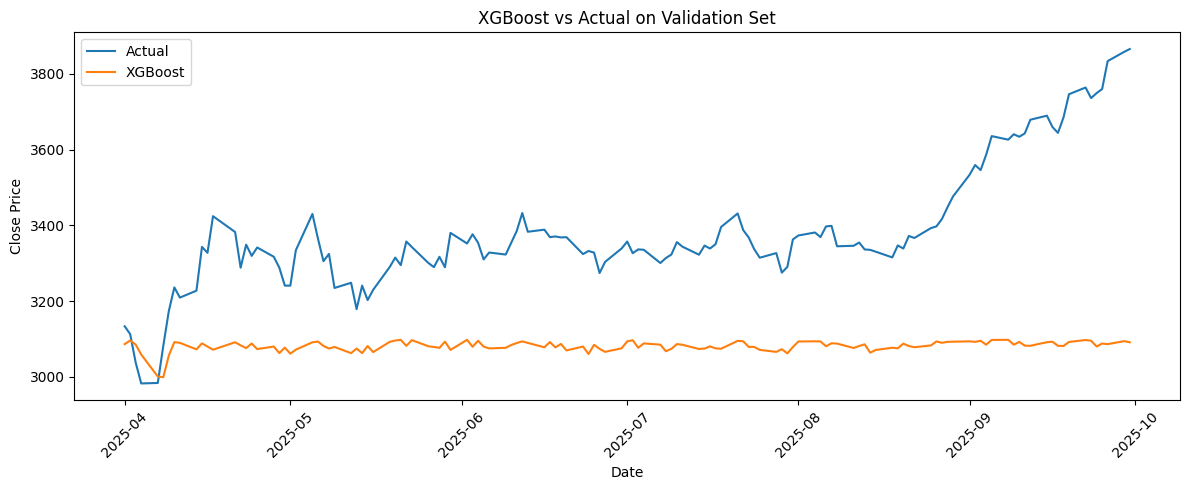

In [11]:
# Vẽ biểu đồ actual vs XGBoost trên tập validation

plt.figure(figsize=(12, 5))
plt.plot(val_df["date"], y_val.values, label="Actual")
plt.plot(val_df["date"], val_xgb_pred, label="XGBoost")
plt.title("XGBoost vs Actual on Validation Set")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

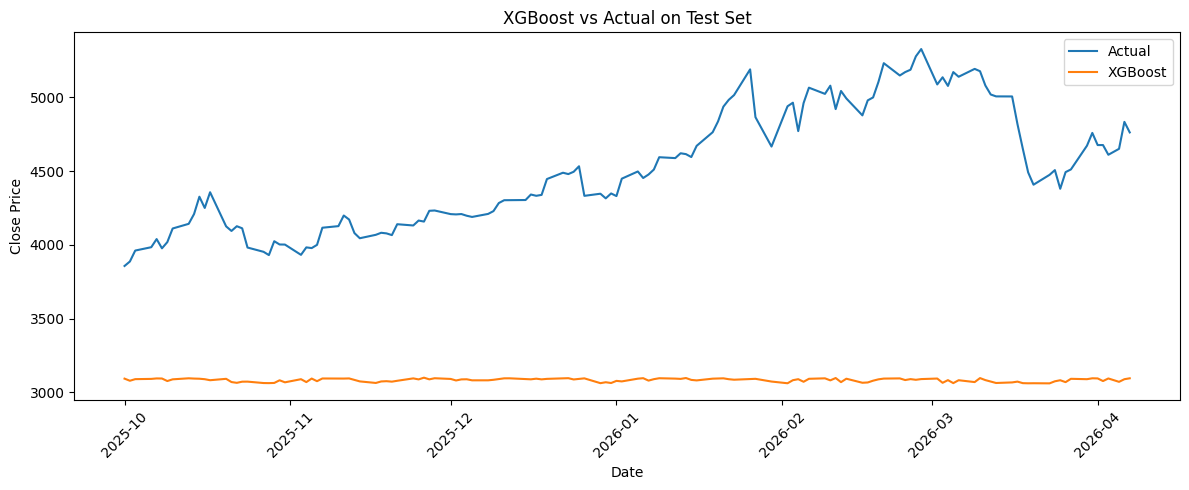

In [12]:
# Vẽ biểu đồ actual vs XGBoost trên tập test

plt.figure(figsize=(12, 5))
plt.plot(test_df["date"], y_test.values, label="Actual")
plt.plot(test_df["date"], test_xgb_pred, label="XGBoost")
plt.title("XGBoost vs Actual on Test Set")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# 1. Kiểm tra target
print(df_model[["date", "close", "target_close_1d"]].head(10))
print(df_model[["date", "close", "target_close_1d"]].tail(10))

# 2. Kiểm tra phân phối target
print(y_train.describe())
print(y_val.describe())
print(y_test.describe())

# 3. Kiểm tra prediction range
print("val pred min/max:", val_xgb_pred.min(), val_xgb_pred.max())
print("test pred min/max:", test_xgb_pred.min(), test_xgb_pred.max())

# 4. Kiểm tra train performance
train_xgb_pred = xgb_model.predict(X_train)
print("=== Performance trên tập train ===")
print(calculate_metrics(y_train, train_xgb_pred))

         date    close  target_close_1d
19 2023-05-01  1982.05          2016.28
20 2023-05-02  2016.28          2039.02
21 2023-05-03  2039.02          2051.11
22 2023-05-04  2051.11          2016.54
23 2023-05-05  2016.54          2021.39
24 2023-05-08  2021.39          2034.17
25 2023-05-09  2034.17          2029.51
26 2023-05-10  2029.51          2015.55
27 2023-05-11  2015.55          2011.15
28 2023-05-12  2011.15          2020.60
          date    close  target_close_1d
764 2026-03-26  4380.03          4492.99
765 2026-03-27  4492.99          4511.25
766 2026-03-30  4511.25          4672.01
767 2026-03-31  4672.01          4758.76
768 2026-04-01  4758.76          4676.42
769 2026-04-02  4676.42          4676.42
770 2026-04-03  4676.42          4610.62
771 2026-04-05  4610.62          4650.89
772 2026-04-06  4650.89          4833.63
773 2026-04-07  4833.63          4762.18
count     491.000000
mean     2298.500835
std       340.292684
min      1820.010000
25%      1980.430000
50% 